# Student admission Dataset

This dataset provides a comprehensive and realistic representation of the college admission landscape in India. It includes information about students from 26 different Indian states, spanning diverse academic backgrounds and career aspirations. The dataset contains a wide range of variables such as demographics, preferred streams, entrance exams (JEE, NEET, CET), Class 12 board performance, extracurricular involvement, admission probability, and final decision. The dataset is synthetically generated but modeled to resemble real patterns observed in Indian admissions. 

In [1]:
# importing required libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the required Dataset
df = pd.read_csv(r"D:\Zephyr Data\project\Student_Admission_Analysis\College_Admission_dataset.csv")
df

,student_id,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
0,250.99,17,other,general,odisha,management,cet,30,95.58,2,0.387,admitted,yes
1,250.99,20,other,ews,gujarat,agriculture,none,0,75.45,2,0.221,rejected,no
2,250.99,19,female,sc,uttar pradesh,pharmacy,cet,120,75.36,10,0.446,rejected,no
3,250.99,18,male,ews,meghalaya,arts,cet,179,52.49,2,0.174,admitted,no
4,250.99,18,male,sc,rajasthan,engineering,jee,295,92.48,7,0.634,admitted,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24750.01,18,female,obc,uttar pradesh,law,none,0,82.67,2,0.273,rejected,no
24996,24750.01,20,other,ews,andhra pradesh,management,none,0,60.66,10,0.258,rejected,no
24997,24750.01,17,male,obc,manipur,pharmacy,cet,195,91.87,6,0.544,rejected,no
24998,24750.01,19,male,ews,andhra pradesh,management,cet,66,50.44,9,0.209,rejected,no


## Cleaning the dataset

In [3]:
# Gettig information of the dataset
df.info() # all columns had correct data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               25000 non-null  float64
 1   age                      25000 non-null  int64  
 2   gender                   25000 non-null  object 
 3   category                 25000 non-null  object 
 4   state                    25000 non-null  object 
 5   preferred_stream         25000 non-null  object 
 6   entrance_exam            25000 non-null  object 
 7   entrance_score           25000 non-null  int64  
 8   board_percentage         25000 non-null  float64
 9   extracurricular_score    25000 non-null  int64  
 10  admission_probability    25000 non-null  float64
 11  admission_status         25000 non-null  object 
 12  scholarship_eligibility  25000 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 2.5+ MB


In [4]:
df.describe()

,student_id,age,entrance_score,board_percentage,extracurricular_score,admission_probability
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,18.492440,77.879760,75.028014,4.990920,0.323997
std,7212.732314,1.116205,120.356125,14.438767,3.158942,0.142427
min,250.990000,17.000000,0.000000,50.440000,0.000000,0.041990
25%,6250.750000,17.000000,0.000000,62.550000,2.000000,0.219000
50%,12500.500000,18.000000,20.000000,75.070000,5.000000,0.319000
75%,18750.250000,19.000000,126.000000,87.640000,8.000000,0.419000
max,24750.010000,20.000000,634.000000,99.530000,10.000000,0.731010


In [5]:
df.head(15)

,student_id,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
0,250.99,17,other,general,odisha,management,cet,30,95.58,2,0.387,admitted,yes
1,250.99,20,other,ews,gujarat,agriculture,none,0,75.45,2,0.221,rejected,no
2,250.99,19,female,sc,uttar pradesh,pharmacy,cet,120,75.36,10,0.446,rejected,no
3,250.99,18,male,ews,meghalaya,arts,cet,179,52.49,2,0.174,admitted,no
4,250.99,18,male,sc,rajasthan,engineering,jee,295,92.48,7,0.634,admitted,yes
5,250.99,20,male,ews,himachal pradesh,architecture,none,0,80.51,8,0.366,admitted,yes
6,250.99,17,female,obc,nagaland,agriculture,cet,57,61.46,10,0.303,rejected,no
7,250.99,19,other,sc,nagaland,medical,neet,333,65.74,3,0.392,rejected,no
8,250.99,17,male,obc,meghalaya,science,none,0,68.35,4,0.205,admitted,no
9,250.99,17,female,sc,meghalaya,pharmacy,cet,125,91.72,4,0.459,admitted,yes


In [6]:
df.tail(15)

,student_id,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
24985,24750.01,18,female,obc,odisha,architecture,none,0,76.50,9,0.355,rejected,no
24986,24750.01,20,other,st,chhattisgarh,agriculture,cet,178,65.04,0,0.229,rejected,no
24987,24750.01,20,male,st,karnataka,engineering,cet,23,99.53,10,0.559,admitted,yes
24988,24750.01,20,other,sc,maharashtra,management,cet,82,83.34,1,0.315,rejected,no
24989,24750.01,19,male,general,jharkhand,pharmacy,cet,59,97.77,0,0.386,admitted,yes
24990,24750.01,17,other,general,manipur,science,cet,138,81.96,10,0.506,rejected,no
24991,24750.01,20,male,ews,sikkim,arts,none,0,51.01,4,0.080,rejected,no
24992,24750.01,17,other,general,meghalaya,pharmacy,cet,22,85.99,1,0.294,rejected,no
24993,24750.01,18,female,obc,madhya pradesh,computer applications,none,0,99.53,1,0.377,rejected,no
24994,24750.01,18,male,general,nagaland,agriculture,cet,146,80.62,0,0.320,admitted,no


In [7]:
# Checking for Null Values
df.isna().sum()

student_id                 0
age                        0
gender                     0
category                   0
state                      0
preferred_stream           0
entrance_exam              0
entrance_score             0
board_percentage           0
extracurricular_score      0
admission_probability      0
admission_status           0
scholarship_eligibility    0
dtype: int64

In [8]:
# Dropping the columns that are not required for the analysis
df.drop(['student_id','age','gender'], axis = 1, inplace = True)

In [9]:
# Making the column headers and elements title format
df.columns = df.columns.str.title()
df = df.apply(lambda col: col.str.title() if col.dtype == 'object' else col)
df['Entrance_Exam'] = df['Entrance_Exam'].str.upper()

In [10]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,24990,24991,24992,24993,24994,24995,24996,24997,24998,24999
Category,General,Ews,Sc,Ews,Sc,Ews,Obc,Sc,Obc,Sc,...,General,Ews,General,Obc,General,Obc,Ews,Obc,Ews,Ews
State,Odisha,Gujarat,Uttar Pradesh,Meghalaya,Rajasthan,Himachal Pradesh,Nagaland,Nagaland,Meghalaya,Meghalaya,...,Manipur,Sikkim,Meghalaya,Madhya Pradesh,Nagaland,Uttar Pradesh,Andhra Pradesh,Manipur,Andhra Pradesh,Tripura
Preferred_Stream,Management,Agriculture,Pharmacy,Arts,Engineering,Architecture,Agriculture,Medical,Science,Pharmacy,...,Science,Arts,Pharmacy,Computer Applications,Agriculture,Law,Management,Pharmacy,Management,Nursing
Entrance_Exam,CET,NONE,CET,CET,JEE,NONE,CET,NEET,NONE,CET,...,CET,NONE,CET,NONE,CET,NONE,NONE,CET,CET,NONE
Entrance_Score,30,0,120,179,295,0,57,333,0,125,...,138,0,22,0,146,0,0,195,66,0
Board_Percentage,95.58,75.45,75.36,52.49,92.48,80.51,61.46,65.74,68.35,91.72,...,81.96,51.01,85.99,99.53,80.62,82.67,60.66,91.87,50.44,87.93
Extracurricular_Score,2,2,10,2,7,8,10,3,4,4,...,10,4,1,1,0,2,10,6,9,4
Admission_Probability,0.387,0.221,0.446,0.174,0.634,0.366,0.303,0.392,0.205,0.459,...,0.506,0.08,0.294,0.377,0.32,0.273,0.258,0.544,0.209,0.348
Admission_Status,Admitted,Rejected,Rejected,Admitted,Admitted,Admitted,Rejected,Rejected,Admitted,Admitted,...,Rejected,Rejected,Rejected,Rejected,Admitted,Rejected,Rejected,Rejected,Rejected,Rejected
Scholarship_Eligibility,Yes,No,No,No,Yes,Yes,No,No,No,Yes,...,No,No,No,No,No,No,No,No,No,No


In [11]:
# Identifying the number of unique values of every column
for i in df.columns:
    print('Column_Name :',i)
    print(df[i].nunique())

Column_Name : Category
5
Column_Name : State
26
Column_Name : Preferred_Stream
12
Column_Name : Entrance_Exam
4
Column_Name : Entrance_Score
616
Column_Name : Board_Percentage
4875
Column_Name : Extracurricular_Score
11
Column_Name : Admission_Probability
691
Column_Name : Admission_Status
2
Column_Name : Scholarship_Eligibility
2


In [12]:
# Creating additional columns to analyse the data better
df['Board_Percentage_Cut'] = pd.cut(df['Board_Percentage'], bins=[50,60,70,80,90,100])
df['Entrance_Score_Cut'] = pd.cut(df['Entrance_Score'], bins = [100,200,300,400,500,600])

# Visualizations

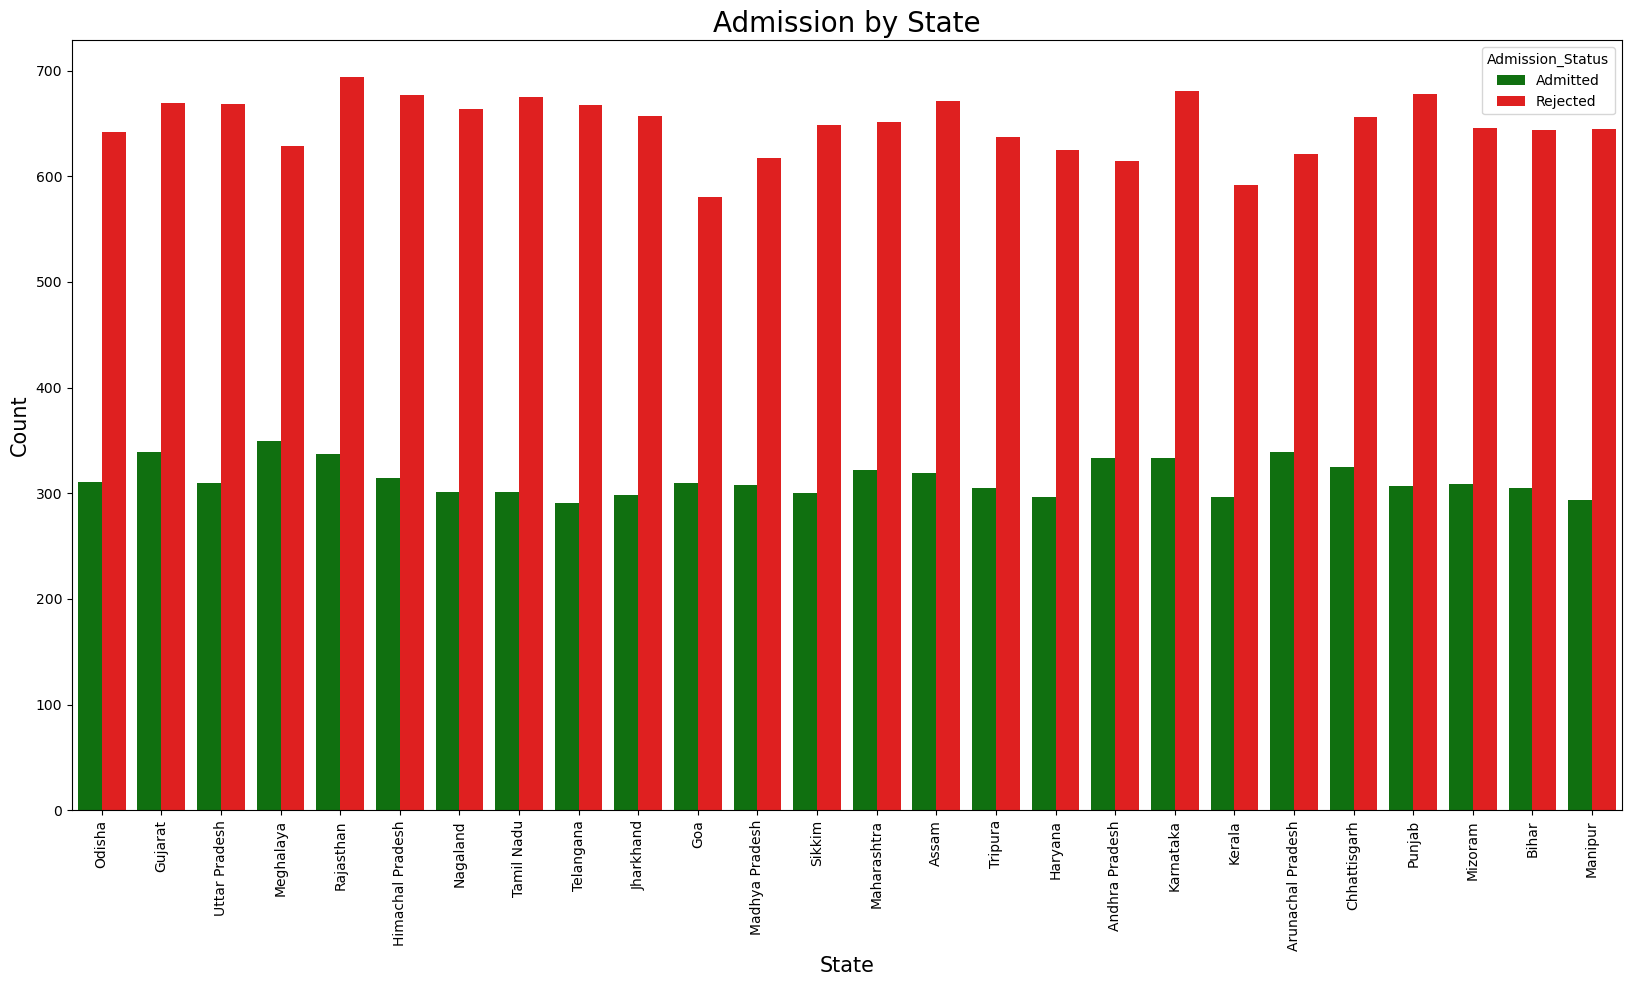

In [13]:
plt.figure(figsize=(20,10))
sns.countplot(x = 'State', hue='Admission_Status',  palette=['green', 'red'], data = df)
plt.title('Admission by State', size=20)
plt.xlabel('State', size=15)
plt.ylabel('Count', size=15)
plt.xticks(rotation =90)
plt.show()

### Observations:
- The graph shows number of students from each state, split by Admitted vs Not Admitted.
- Certain states have 
	a. More applicants
	b. Better academic preparation
	c. Higher awareness of the institution
- States with higher applicant quality will continue to dominate admissions.

### Suggestions:
- Increase outreach and awareness in low-admission states.
- Analyze state-wise academic support or eligibility gaps.


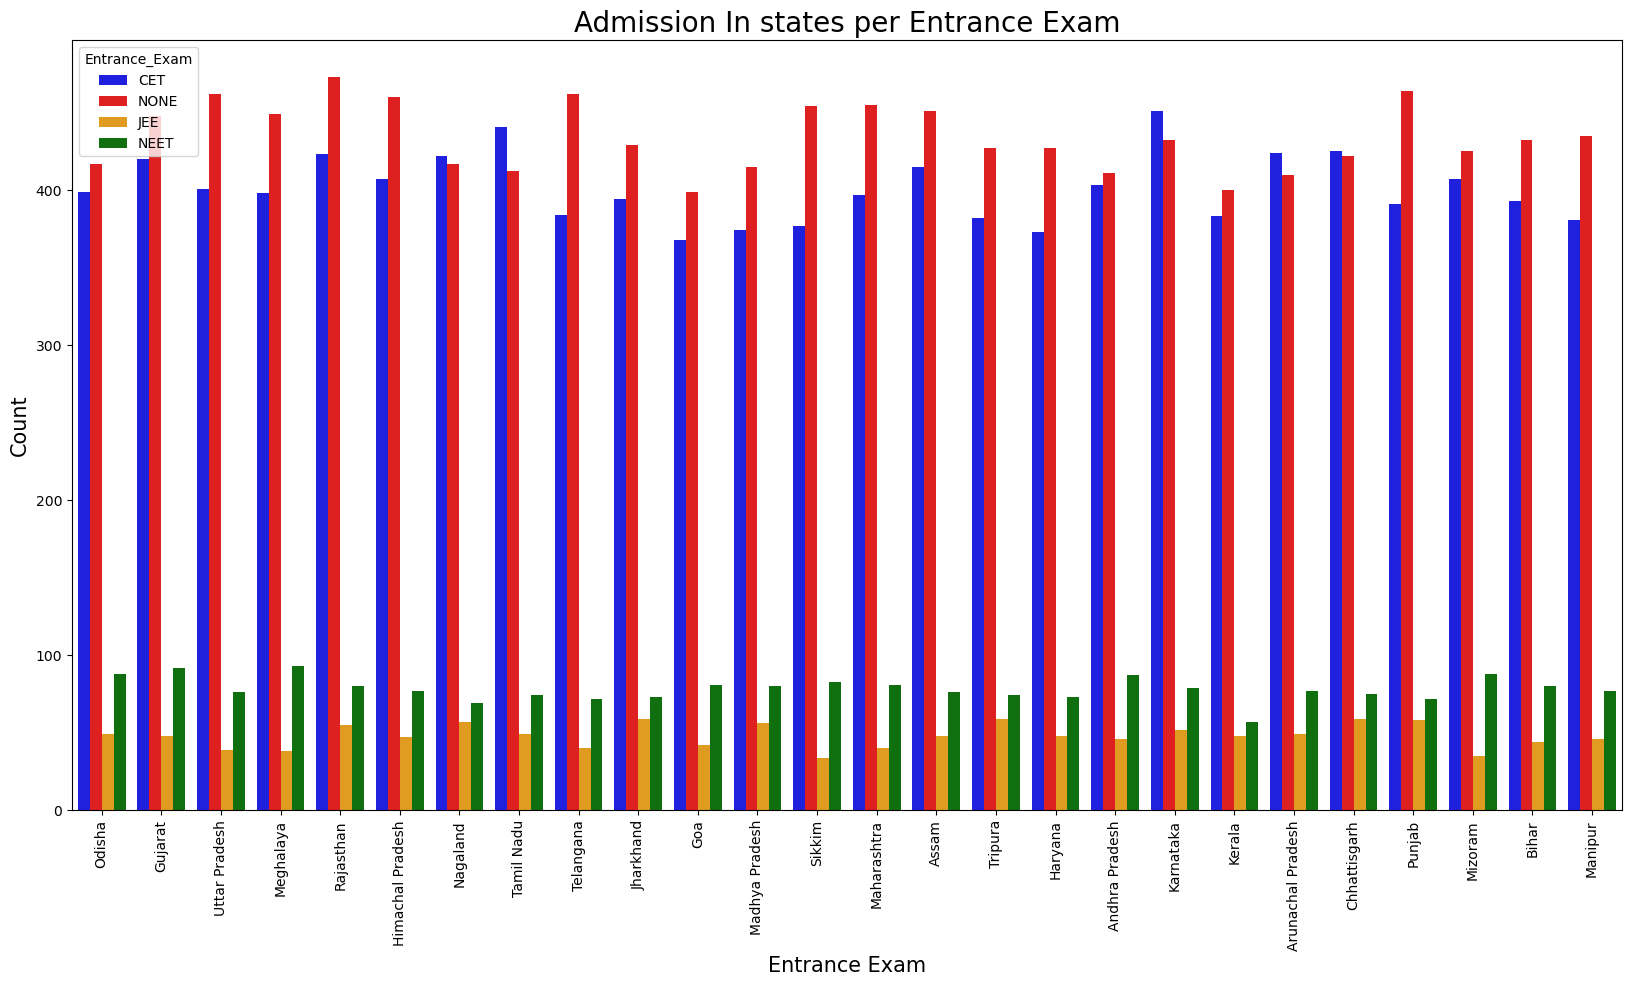

In [14]:
plt.figure(figsize=(20,10))
sns.countplot(x = 'State', hue='Entrance_Exam', palette= ['blue','red','orange','green'],data = df)
plt.title('Admission In states per Entrance Exam', size=20)
plt.xlabel('Entrance Exam', size=15)
plt.ylabel('Count', size=15)
plt.xticks(rotation =90)
plt.show()

### Observations
- Students from different states prefer or appear for different entrance exams. 
- Entrance exam popularity varies by region.
- Coaching availability and exam awareness differ state-wise.
- States aligned with popular exams will have better admission chances.

### Suggestions:
- Accept multiple entrance exams fairly.
- Normalizing scores across exams.

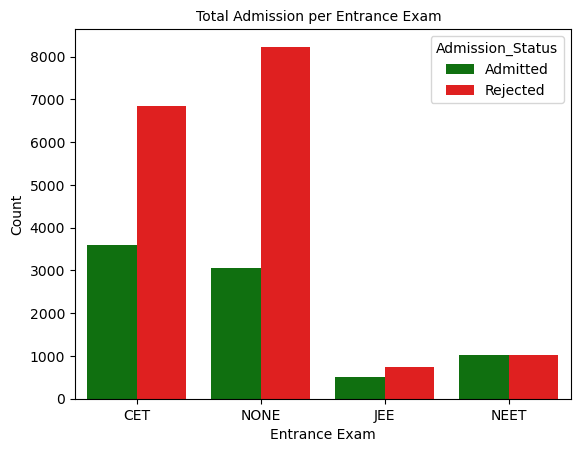

In [15]:
sns.countplot(x = 'Entrance_Exam', hue='Admission_Status', palette= ['green','red'],data = df)
plt.title('Total Admission per Entrance Exam  ', size=10)
plt.xlabel('Entrance Exam', size=10)
plt.ylabel('Count', size=10)
plt.show()

### Observations:
- CET entrance exams show higher admission success rates.
- JEE and NEET are better aligned with admission criteria
- They are more competitive.
- Students will prefer exams with higher success rates.
- Competition in those exams will increase.

### Suggestions:
- Regularly review exam weightage.
- Avoid over-dependence on a single exam.

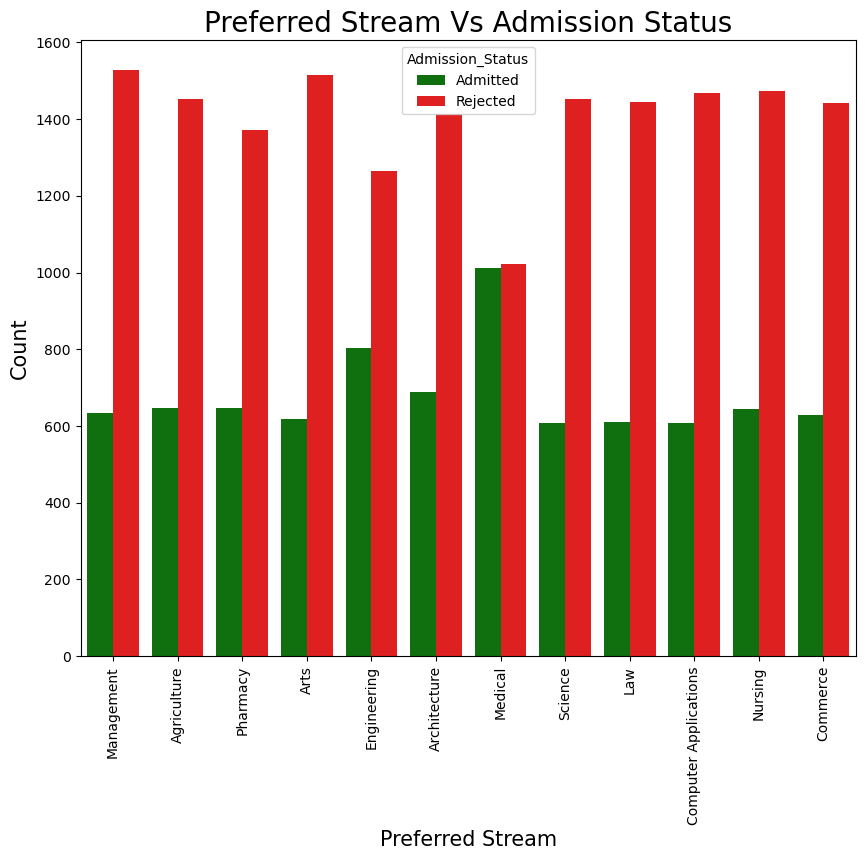

In [16]:
plt.figure(figsize=(10,8))
sns.countplot(x = 'Preferred_Stream', hue='Admission_Status', palette= ['green','red'],data = df)
plt.title('Preferred Stream Vs Admission Status', size=20)
plt.xlabel('Preferred Stream', size=15)
plt.ylabel('Count', size=15)
plt.xticks(rotation =90)
plt.show()

### Observations:
- Some streams have more admitted students than others.
- Popular streams have:
	a. More seats
	b. Higher demand
- Some streams are more selective.
- Popular streams will remain competitive.
- Less popular seats will have seat vacancies.

### Suggestions:
- Balance seat allocation.
- Promote lesser-known streams with strong career outcomes.

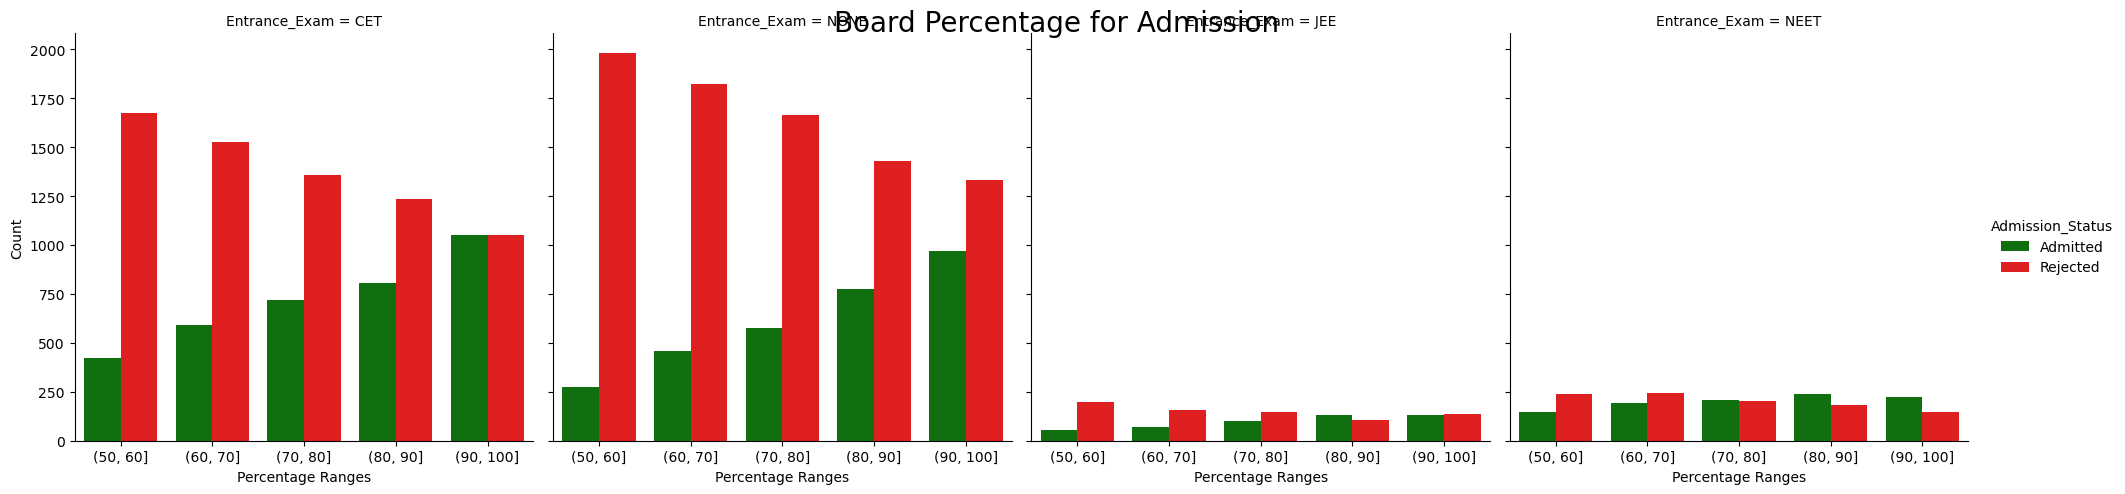

In [17]:
sns.catplot(x = 'Board_Percentage_Cut', hue='Admission_Status', col = 'Entrance_Exam',  kind = 'count', palette= ['green','red'], data = df).set_axis_labels("Percentage Ranges", "Count")
plt.suptitle('Board Percentage for Admission', size = 20)
plt.show()

### Observations:
- Higher board percentage ranges show more admissions.
- Board percentage is a key eligibility criterion.
- Higher scores indicate better academic readiness. 
- Cut-offs may increase over time.
- Competition will intensify in top score brackets.

### Suggestions:
- Introduce flexibility near cut-off margins.
- Consider percentile-based evaluation.

C:\Users\amolc\AppData\Local\Temp\ipykernel_31688\3565273575.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = 'Extracurricular_Score',  col= 'Entrance_Exam',  kind = 'count', palette = 'Blues', data = df[df['Admission_Status']=='Admitted']).set_axis_labels("Extracurricular Score", "Count")


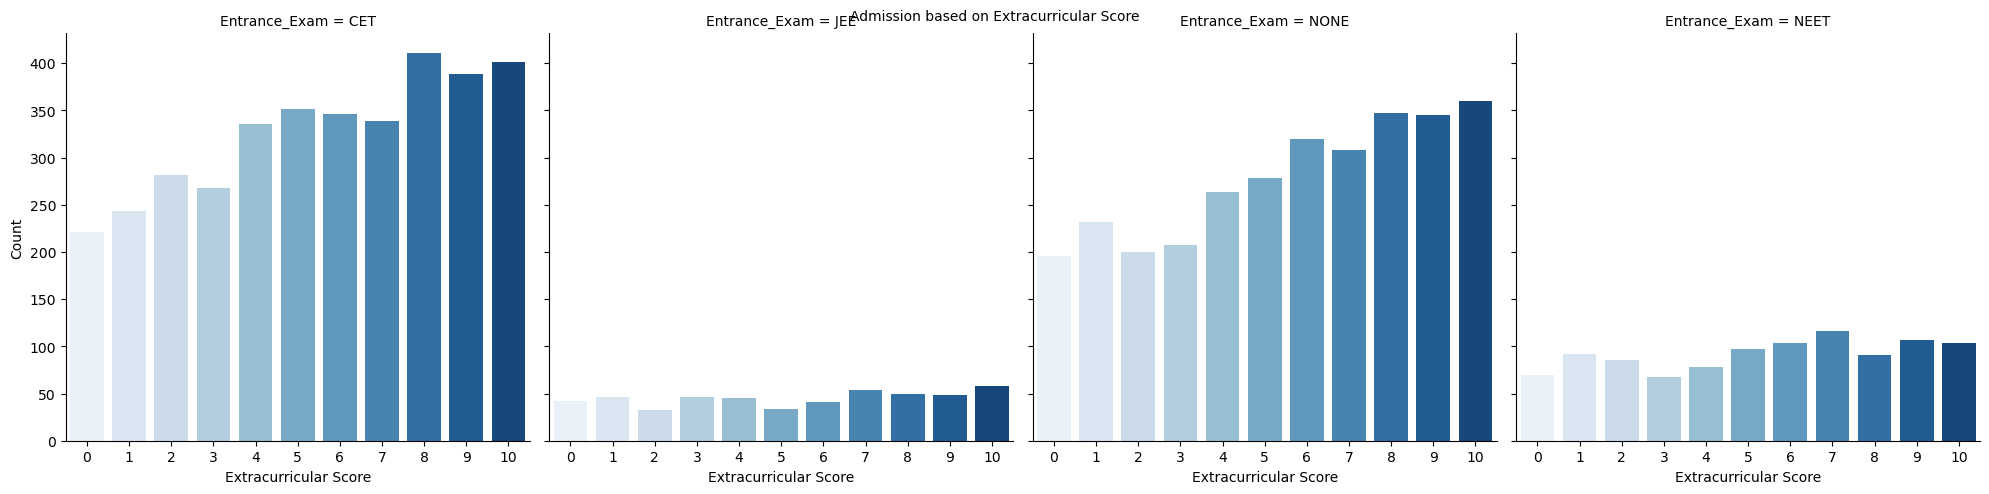

In [18]:
sns.catplot(x = 'Extracurricular_Score',  col= 'Entrance_Exam',  kind = 'count', palette = 'Blues', data = df[df['Admission_Status']=='Admitted']).set_axis_labels("Extracurricular Score", "Count")
plt.suptitle('Admission based on Extracurricular Score', size=10)
plt.show()

### Observations:
- Students with higher extracurricular scores have better admission chances.
- Institutions value holistic development, not just academics.
- Extracurriculars will gain more importance.
- Students will focus on all-round profiles.

### Suggestions:
- Clearly define extracurricular weightage.
- Standardize scoring to avoid subjectivity.

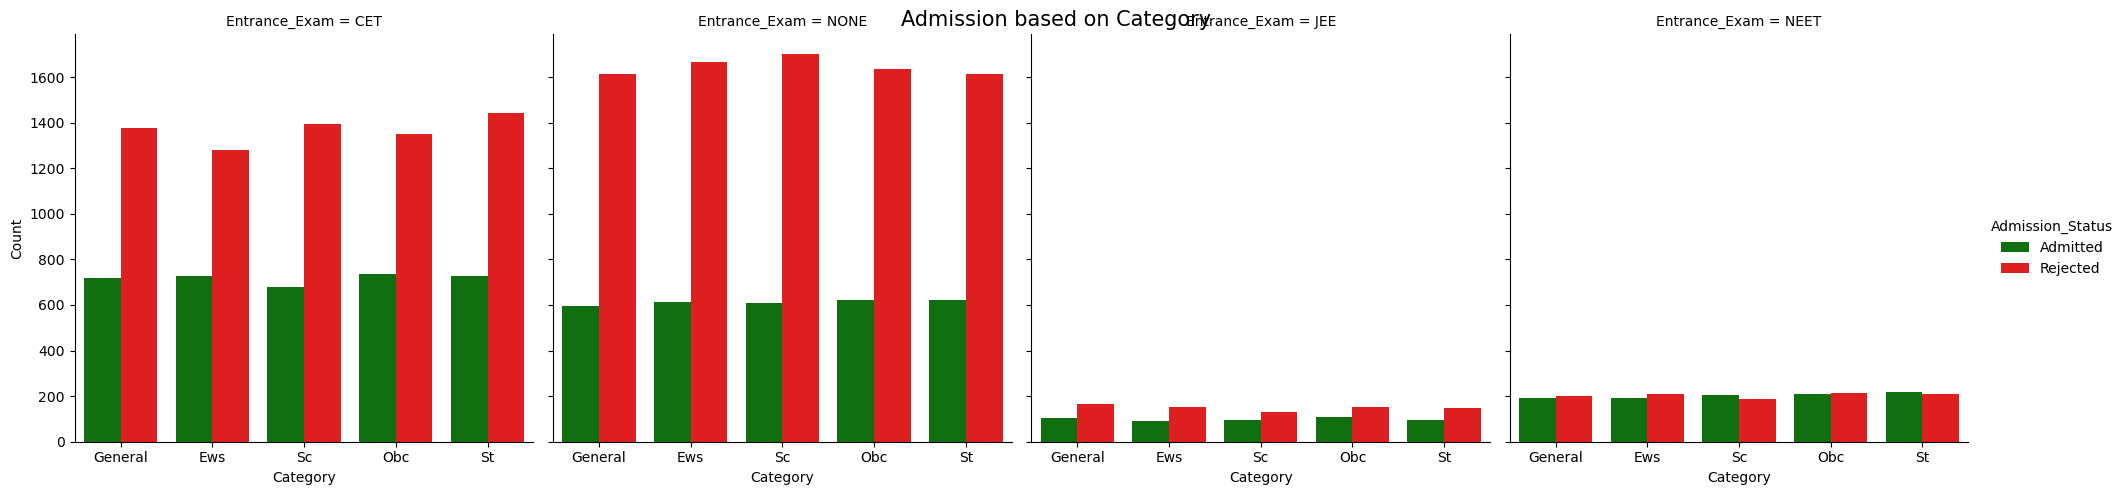

In [19]:
sns.catplot(x = 'Category', col= 'Entrance_Exam',  hue='Admission_Status',kind = 'count', palette=['green','red'], data = df).set_axis_labels("Category", "Count")
plt.suptitle('Admission based on Category', size=15)
plt.show()

### Observations:
- Admission outcomes vary by category and entrance exam combination.
- Reservation policies and exam difficulty differ.
- Category-based cut-offs influence results.
- Admission patterns will remain structured by policy. 
- Certain category–exam combinations will dominate.

### Suggestions:
- Monitor fairness across categories. 
- Periodically review category-based criteria.

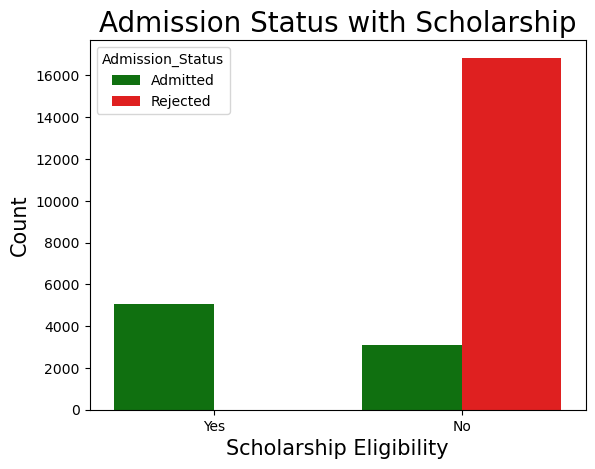

In [20]:
sns.countplot(x='Scholarship_Eligibility', palette=['green','red'],hue='Admission_Status',data=df)
plt.title('Admission Status with Scholarship', size=20)
plt.xlabel('Scholarship Eligibility', size=15)
plt.ylabel('Count', size=15)
plt.show()

### Observations:
- Scholarship-eligible students show higher admission rates.
- Scholarships attract strong candidates. 
- Financial support improves enrolment decisions.
- Scholarships will continue to influence admissions positively.

### Suggestions:
- Expand scholarship programs. 
- Target high-potential but underprivileged students.

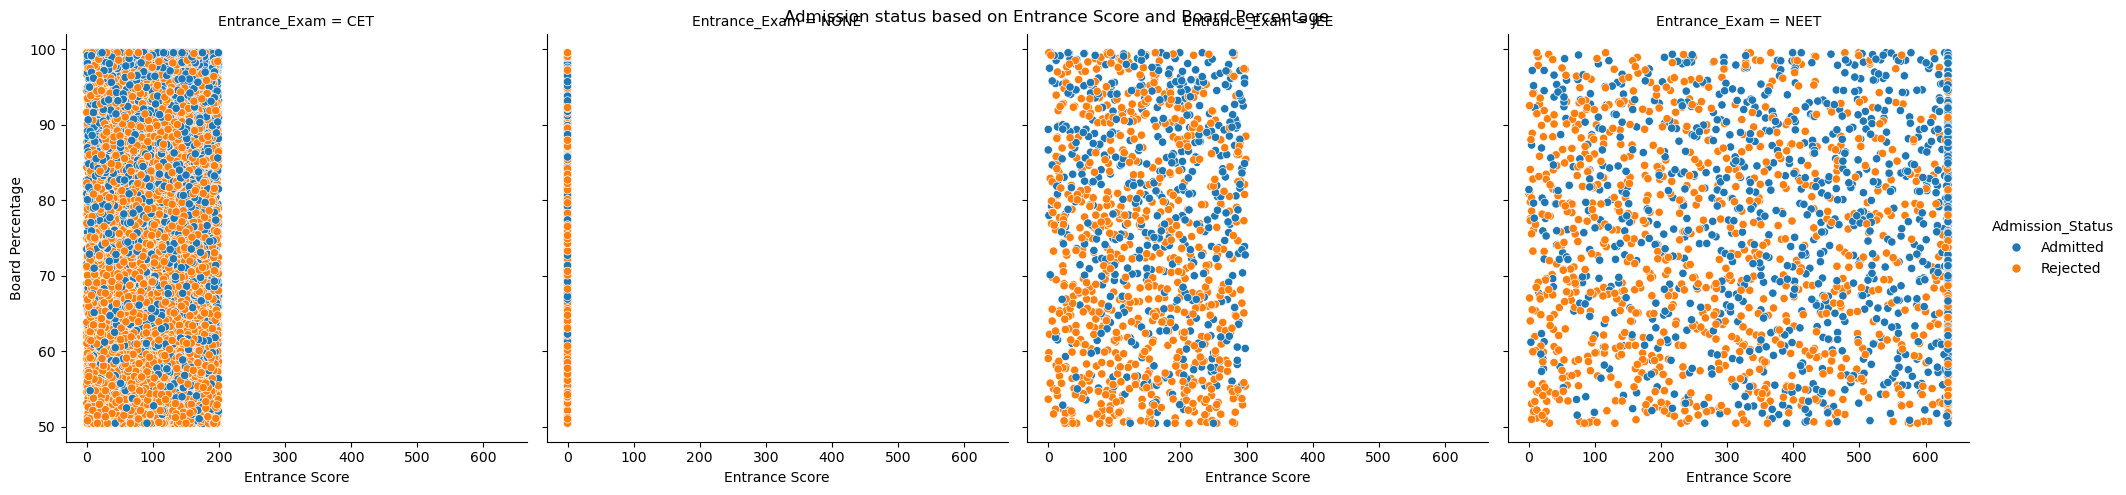

In [21]:
sns.relplot(kind ='scatter', x= 'Entrance_Score', y = 'Board_Percentage', hue = 'Admission_Status', col='Entrance_Exam' ,data =  df).set_axis_labels('Entrance Score', 'Board Percentage')
plt.suptitle('Admission status based on Entrance Score and Board Percentage')
plt.xlabel('Entrance Score')
plt.ylabel('Board Percentage')
plt.show()

### Observations:
- A positive relationship between entrance score and board percentage.
- Strong academic students tend to perform well consistently.
- These variables will remain strong predictors in models.
### Suggestions:
- Use both scores together for better evaluation. 
- Avoid relying on only one metric.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Category                 25000 non-null  object  
 1   State                    25000 non-null  object  
 2   Preferred_Stream         25000 non-null  object  
 3   Entrance_Exam            25000 non-null  object  
 4   Entrance_Score           25000 non-null  int64   
 5   Board_Percentage         25000 non-null  float64 
 6   Extracurricular_Score    25000 non-null  int64   
 7   Admission_Probability    25000 non-null  float64 
 8   Admission_Status         25000 non-null  object  
 9   Scholarship_Eligibility  25000 non-null  object  
 10  Board_Percentage_Cut     25000 non-null  category
 11  Entrance_Score_Cut       7423 non-null   category
dtypes: category(2), float64(2), int64(2), object(6)
memory usage: 2.0+ MB


## Feature Encoding

In [27]:
#Using Label Encoder for encoding
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
le = LabelEncoder()
for i in ['Admission_Status','Scholarship_Eligibility']:
    df[i]=le.fit_transform(df[i])

# Using onehotencoder for categorical data
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[['Category', 'Entrance_Exam', 'Preferred_Stream','State']])

In [28]:
encoded_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out(['Category', 'Entrance_Exam', 'Preferred_Stream','State']))
df = pd.concat([df, encoded_df], axis=1)


In [29]:
pd.set_option('display.max_columns', None)

In [30]:
df

,Category,State,Preferred_Stream,Entrance_Exam,Entrance_Score,Board_Percentage,Extracurricular_Score,Admission_Probability,Admission_Status,Scholarship_Eligibility,Board_Percentage_Cut,Entrance_Score_Cut,Category_General,Category_Obc,Category_Sc,Category_St,Entrance_Exam_JEE,Entrance_Exam_NEET,Entrance_Exam_NONE,Preferred_Stream_Architecture,Preferred_Stream_Arts,Preferred_Stream_Commerce,Preferred_Stream_Computer Applications,Preferred_Stream_Engineering,Preferred_Stream_Law,Preferred_Stream_Management,Preferred_Stream_Medical,Preferred_Stream_Nursing,Preferred_Stream_Pharmacy,Preferred_Stream_Science,State_Arunachal Pradesh,State_Assam,State_Bihar,State_Chhattisgarh,State_Goa,State_Gujarat,State_Haryana,State_Himachal Pradesh,State_Jharkhand,State_Karnataka,State_Kerala,State_Madhya Pradesh,State_Maharashtra,State_Manipur,State_Meghalaya,State_Mizoram,State_Nagaland,State_Odisha,State_Punjab,State_Rajasthan,State_Sikkim,State_Tamil Nadu,State_Telangana,State_Tripura,State_Uttar Pradesh
0,General,Odisha,Management,CET,30,95.58,2,0.387,0,1,"(90, 100]",NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Ews,Gujarat,Agriculture,NONE,0,75.45,2,0.221,1,0,"(70, 80]",NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Sc,Uttar Pradesh,Pharmacy,CET,120,75.36,10,0.446,1,0,"(70, 80]","(100.0, 200.0]",0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,Ews,Meghalaya,Arts,CET,179,52.49,2,0.174,0,0,"(50, 60]","(100.0, 200.0]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Sc,Rajasthan,Engineering,JEE,295,92.48,7,0.634,0,1,"(90, 100]","(200.0, 300.0]",0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,Obc,Uttar Pradesh,Law,NONE,0,82.67,2,0.273,1,0,"(80, 90]",NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24996,Ews,Andhra Pradesh,Management,NONE,0,60.66,10,0.258,1,0,"(60, 70]",NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24997,Obc,Manipur,Pharmacy,CET,195,91.87,6,0.544,1,0,"(90, 100]","(100.0, 200.0]",0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24998,Ews,Andhra Pradesh,Management,CET,66,50.44,9,0.209,1,0,"(50, 60]",NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Machine Learning Algorithm
This is a classification problem to find out if the students will be admitted or rejected.

### Logistic Regressor

In [31]:
# Importing the necessary libraries.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [32]:
# Feature Selection
x= df.drop(['State','Category', 'Preferred_Stream','Entrance_Exam','Board_Percentage_Cut','Entrance_Score_Cut','Admission_Status'], axis=1) 
y=df['Admission_Status']

In [33]:
# Scaling the data
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_scale = ss.fit_transform(x)

In [34]:
# splitting into training and testing dataset
x_train,x_test,y_train,y_test = train_test_split(x_scale,y,test_size=0.2,random_state=42)

In [35]:
# Training the model using logistic regressor
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [36]:
lry_pred = lr.predict(x_test)

In [37]:
x_test

array([[ 0.98144239, -1.01312713,  0.95257838, ..., -0.19961697,
        -0.19787717, -0.20177383],
       [-0.64709061,  1.42895842,  1.58571435, ..., -0.19961697,
        -0.19787717, -0.20177383],
       [-0.64709061,  1.5307697 , -0.63026153, ..., -0.19961697,
        -0.19787717, -0.20177383],
       ...,
       [ 0.9232805 , -1.137794  , -0.31369354, ..., -0.19961697,
        -0.19787717, -0.20177383],
       [-0.64709061, -1.65239116, -1.26339749, ..., -0.19961697,
        -0.19787717, -0.20177383],
       [-0.64709061,  0.20306749,  0.31944242, ..., -0.19961697,
        -0.19787717, -0.20177383]])

In [38]:
## Model Evaluation
lracc =  accuracy_score(lry_pred,y_test)
lrcon = confusion_matrix(lry_pred,y_test)
lrcls =  classification_report(lry_pred,y_test)

print('Accuarcy Score:',lracc)
print('Confusion Matrix:\n',lrcon)
print('Classification Score:\n',lrcls)

Accuarcy Score: 0.8754
Confusion Matrix:
 [[1021   27]
 [ 596 3356]]
Classification Score:
               precision    recall  f1-score   support

           0       0.63      0.97      0.77      1048
           1       0.99      0.85      0.92      3952

    accuracy                           0.88      5000
   macro avg       0.81      0.91      0.84      5000
weighted avg       0.92      0.88      0.88      5000



In [39]:
# Testing on New Data
lrnd = x.iloc[[2]]
lrnd_scale = ss.transform(lrnd)
lrnd1 = lr.predict(lrnd_scale)
print(lrnd1)

[1]


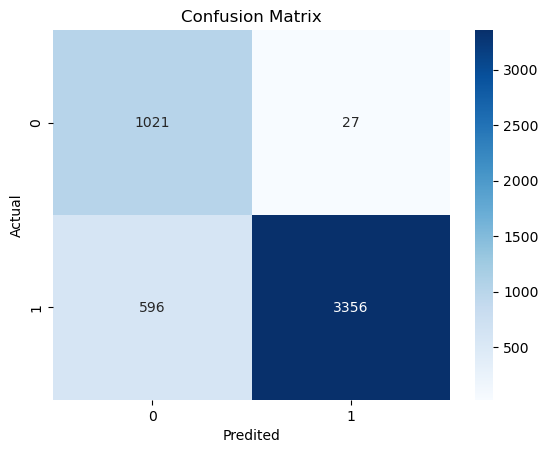

In [40]:
sns.heatmap(lrcon, annot=True, fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predited')
plt.ylabel('Actual')
plt.show()

## KNN Classifier

In [41]:
# importing necessary libraries
from sklearn.neighbors import KNeighborsClassifier

In [42]:
#training the model
knc = KNeighborsClassifier(n_neighbors= 11)
knc.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=11)

In [43]:
kncy_pred = knc.predict(x_test)

In [44]:
#Evaluating the Model
kncacc =  accuracy_score(kncy_pred,y_test)
knccon = confusion_matrix(kncy_pred,y_test)
knccls =  classification_report(kncy_pred,y_test)

print('Accuarcy Score:',kncacc)
print('Confusion Matrix:\n',knccon)
print('Classification Score:\n',knccls)

Accuarcy Score: 0.8066
Confusion Matrix:
 [[ 744   94]
 [ 873 3289]]
Classification Score:
               precision    recall  f1-score   support

           0       0.46      0.89      0.61       838
           1       0.97      0.79      0.87      4162

    accuracy                           0.81      5000
   macro avg       0.72      0.84      0.74      5000
weighted avg       0.89      0.81      0.83      5000



In [45]:
kncnd1=knc.predict(lrnd_scale)
print(kncnd1)

[1]


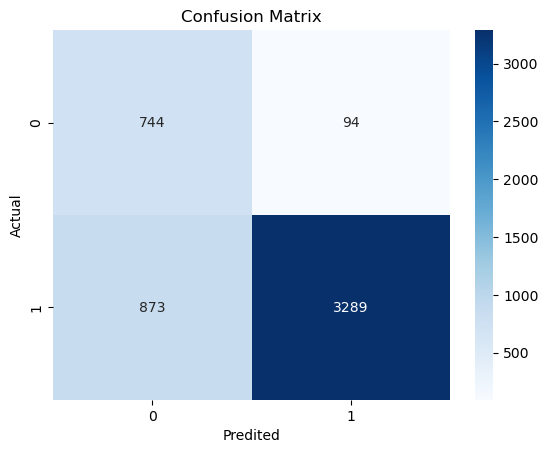

In [46]:
sns.heatmap(knccon, annot=True, fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predited')
plt.ylabel('Actual')
plt.show()

## Decision Tree Classifier

In [47]:
# importing required libraries
from sklearn.tree import DecisionTreeClassifier

In [48]:
#Spliting the training and testing dataset
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2, random_state=42)
dtc = DecisionTreeClassifier(max_depth = 3, random_state = 42)
dtc.fit(x_train,y_train)   # training the model

DecisionTreeClassifier(max_depth=3, random_state=42)

In [49]:
dtcy_pred = dtc.predict(x_test)

In [50]:
#Evaluating the Model
dtcacc =  accuracy_score(dtcy_pred,y_test)
dtccon = confusion_matrix(dtcy_pred,y_test)
dtccls =  classification_report(dtcy_pred,y_test)

print('Accuarcy Score:',dtcacc)
print('Confusion Matrix:\n',dtccon)
print('Classification Score:\n',dtccls)

Accuarcy Score: 0.8776
Confusion Matrix:
 [[1005    0]
 [ 612 3383]]
Classification Score:
               precision    recall  f1-score   support

           0       0.62      1.00      0.77      1005
           1       1.00      0.85      0.92      3995

    accuracy                           0.88      5000
   macro avg       0.81      0.92      0.84      5000
weighted avg       0.92      0.88      0.89      5000



In [51]:
#Testing on new data
dtcnd = x.iloc[[8]]
dtcnd1=dtc.predict(dtcnd)
print(kncnd1)

[1]


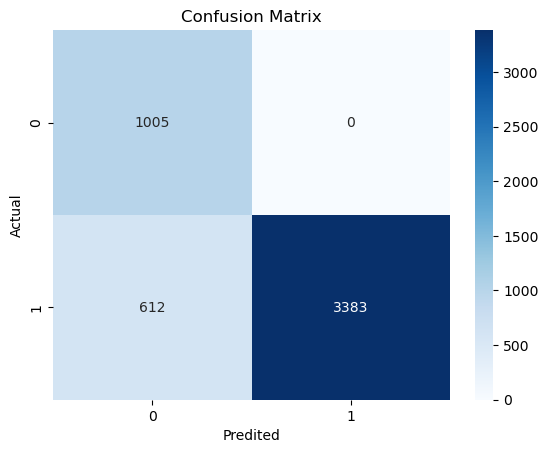

In [52]:
sns.heatmap(dtccon, annot=True, fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predited')
plt.ylabel('Actual')
plt.show()

## RandomForestClassifier

In [53]:
# importing required libraries
from sklearn.ensemble import RandomForestClassifier

In [54]:
# Training the model
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [55]:
rfcy_pred = rfc.predict(x_test)

In [56]:
#Evaluating the Model
rfcacc =  accuracy_score(rfcy_pred,y_test)
rfccon = confusion_matrix(rfcy_pred,y_test)
rfccls =  classification_report(rfcy_pred,y_test)

print('Accuarcy Score:',rfcacc)
print('Confusion Matrix:\n',rfccon)
print('Classification Score:\n',rfccls)

Accuarcy Score: 0.8704
Confusion Matrix:
 [[1057   88]
 [ 560 3295]]
Classification Score:
               precision    recall  f1-score   support

           0       0.65      0.92      0.77      1145
           1       0.97      0.85      0.91      3855

    accuracy                           0.87      5000
   macro avg       0.81      0.89      0.84      5000
weighted avg       0.90      0.87      0.88      5000



In [57]:
#Testing on new data
dtcnd = x.iloc[[8]]
rfcnd1=rfc.predict(dtcnd)
print(rfcnd1)

[0]


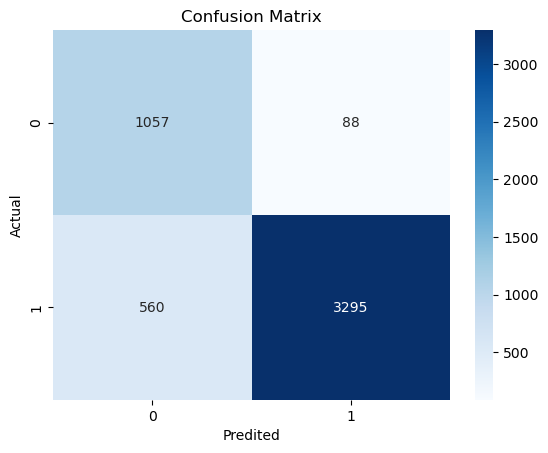

In [58]:
sns.heatmap(rfccon, annot=True, fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predited')
plt.ylabel('Actual')
plt.show()

### SVC

In [59]:
# importing required libraries
from sklearn.svm import SVC
from sklearn.metrics import precision_score

In [60]:
# Training the model
x_train,x_test,y_train,y_test = train_test_split(x_scale,y,test_size=0.2,random_state=42)
svcm = SVC(kernel = 'poly',class_weight='balanced')
svcm.fit(x_train,y_train)

SVC(class_weight='balanced', kernel='poly')

In [61]:
svcy_pred = svcm.predict(x_test)

In [62]:
#Evaluating the Model
svcacc =  accuracy_score(svcy_pred,y_test)
svccon = confusion_matrix(svcy_pred,y_test)
svccls =  classification_report(svcy_pred,y_test)
svcprs = precision_score(svcy_pred,y_test)

print('Accuarcy Score:',svcacc)
print('Confusion Matrix:\n',svccon)
print('Classification Score:\n',svccls)
print('Precision Score:\n',svcprs)

Accuarcy Score: 0.867
Confusion Matrix:
 [[1059  107]
 [ 558 3276]]
Classification Score:
               precision    recall  f1-score   support

           0       0.65      0.91      0.76      1166
           1       0.97      0.85      0.91      3834

    accuracy                           0.87      5000
   macro avg       0.81      0.88      0.83      5000
weighted avg       0.90      0.87      0.87      5000

Precision Score:
 0.968371268105232


In [63]:
#Testing on new data
svcnd1=svcm.predict(lrnd_scale)
print(svcnd1)

[1]


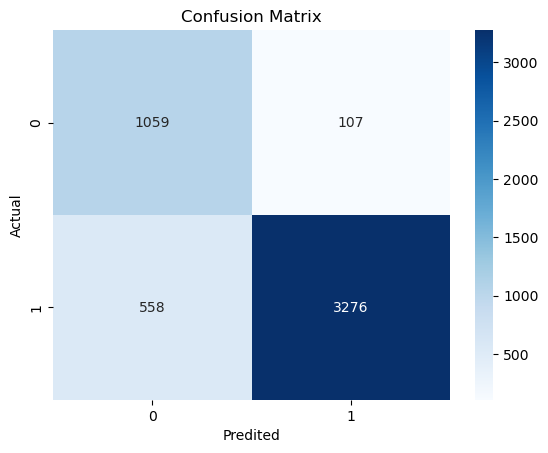

In [64]:
sns.heatmap(svccon, annot=True, fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predited')
plt.ylabel('Actual')
plt.show()

## Comparison Graph

In [65]:
algorithms = ['Logistic Regression', 'KNN','Decision Tree', 'RandomForestClassifier','Support Vector Classifier']
accuracies = [lracc,kncacc,dtcacc,rfcacc,svcacc]

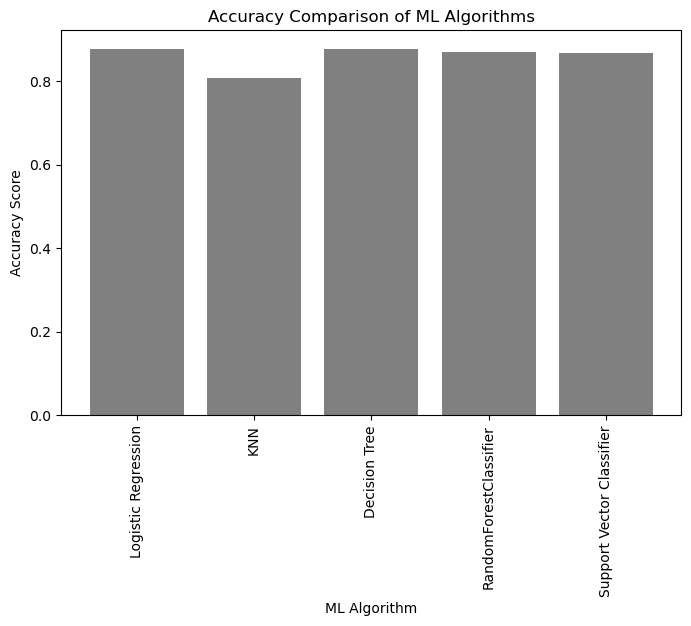

In [66]:
plt.figure(figsize=(8, 5))
plt.bar(algorithms, accuracies, color='Grey')
plt.xlabel('ML Algorithm')
plt.xticks(rotation = 90)
plt.ylabel('Accuracy Score')
plt.title('Accuracy Comparison of ML Algorithms')
plt.show()